In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [4]:
minla = -68
maxla = -63

fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'

extent_ac = [138,152,minla,maxla]
extent_ea=[60,160,-70,-60]

# glorys first. need to interpolate before loading out of dask
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2]).sel(latitude=slice(extent_ac[2],extent_ac[3])).sel(longitude=slice(extent_ac[0],extent_ac[1]))

/tmp/ipykernel_3151481/2827866174.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2]).sel(latitude=slice(extent_ac[2],extent_ac[3])).sel(longitude=slice(extent_ac[0],extent_ac[1]))


In [5]:
# compute density etc
glorys['pres'] = conversions.p_from_z(-glorys.depth,glorys.latitude.mean())
glorys['asal'] = conversions.SA_from_SP(glorys.so,glorys.pres,glorys.longitude,glorys.latitude)
glorys['ctemp'] = conversions.CT_from_pt(glorys.asal,glorys.thetao)

In [6]:
glorys['sigma0'] = density.sigma0(glorys.asal,glorys.ctemp)

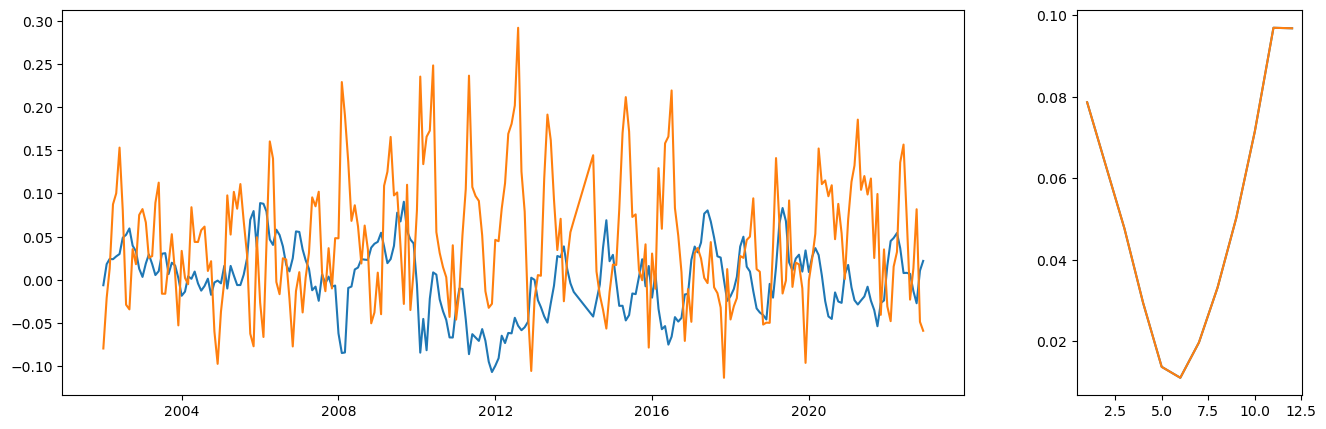

In [7]:
glorys143 = glorys.sel(longitude=143,method='nearest')

# drop dodgy vlaues
glorys143=glorys143.drop_sel(time=[pd.Timestamp(2014,5,1),pd.Timestamp(2014,4,1),pd.Timestamp(2014,6,1),pd.Timestamp(2014,3,1),pd.Timestamp(2014,2,1)])#.plot()

sigshelf = glorys143.sigma0.sel(latitude=-66.3,method='nearest').sel(depth=300,method='nearest')
sigocean = glorys143.sigma0.sel(latitude=-65.3,method='nearest').sel(depth=300,method='nearest')

sigdiff = sigshelf - sigocean
sigdiff2 = glorys143.sigma0.differentiate('latitude').sel(latitude=slice(-66.3,-65.3)).sel(depth=300,method='nearest').max('latitude')


fig,ax=plt.subplots(1,2,figsize=(16,5),width_ratios=[4,1])
#ax[0].plot(sigdiff.time,sigdiff)

sigdiff_c = sigdiff.groupby('time.month').mean()
sigdiff2_c = sigdiff.groupby('time.month').mean()

ax[1].plot(sigdiff_c.month,sigdiff_c)
ax[1].plot(sigdiff_c.month,sigdiff2_c)

ax[0].plot(sigdiff.time,sigdiff.groupby('time.month')-sigdiff_c)
ax[0].plot(sigdiff2.time,sigdiff2.groupby('time.month')-sigdiff2_c)

In [8]:
tmp = sigdiff.groupby('time.month')-sigdiff_c
tmp.where(tmp==tmp.min(),drop=True)

<xarray.DataArray 'sigma0' (time: 1)> Size: 8B
array([-0.10674096])
Coordinates:
  * time       (time) datetime64[ns] 8B 2011-12-01
    longitude  (time) float32 4B 143.0
    depth      (time) float32 4B 318.1
    month      (time) int64 8B 12
Attributes:
    units:          1e-3
    standard_name:  sea_water_salinity
    long_name:      Salinity
    cell_methods:   area: mean
    unit_long:      Practical Salinity Unit
    valid_max:      48.37031
    valid_min:      0.0

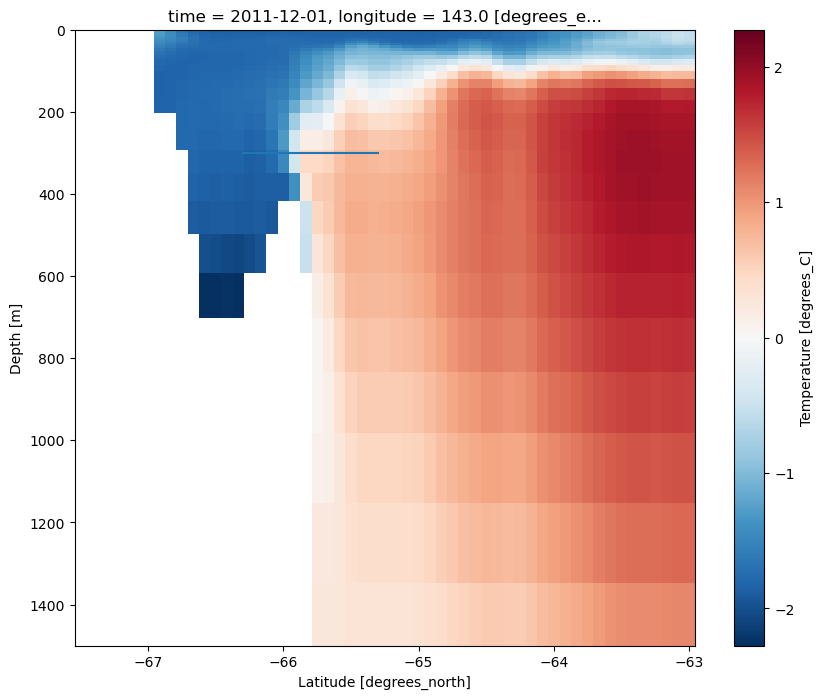

In [9]:
fig, ax = plt.subplots(figsize=(10,8))
glorys143.thetao.sel(time=pd.Timestamp(2011,12,1)).plot(ax=ax)
ax.set_ylim([0,1500])
ax.plot([-66.3,-65.3],[300,300])
ax.invert_yaxis()



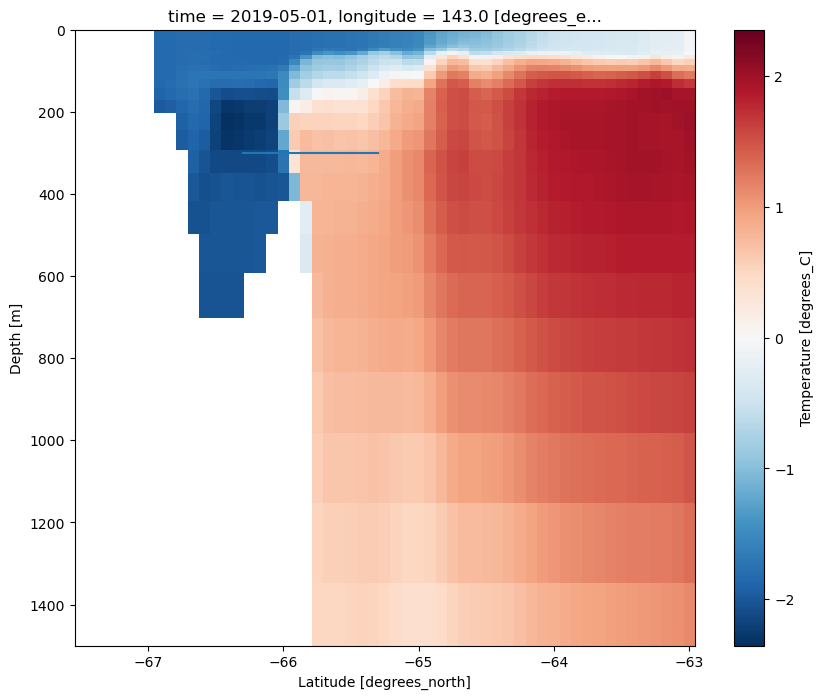

In [10]:
fig, ax = plt.subplots(figsize=(10,8))
glorys143.thetao.sel(time=pd.Timestamp(2019,5,1)).plot(ax=ax)
ax.set_ylim([0,1500])
ax.plot([-66.3,-65.3],[300,300])
ax.invert_yaxis()

In [11]:
t1 = glorys.time[0]
t2 = glorys.time[-1]

In [12]:
glorys_gi = xr.open_dataarray('glorys_gi.nc')

In [13]:
# prepare other data
sa_gyre = fns.seasonal_anomaly(glorys_gi.sel(time=slice(t1,t2)))
sa_glorys = fns.seasonal_anomaly(glorys143)


ssn_gyre = fns.season_split(sa_gyre)
ssn_glorys = fns.season_split(sa_glorys)



In [14]:

from datetime import datetime
from dateutil.relativedelta import relativedelta as rd


In [15]:
def plot_transect(data,ax,title,vmin,vmax):
    im=data.plot.contourf(ax=ax,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance,add_colorbar=False,levels=40)
    #ax.set_title(title)
    ax.set_ylim([-1500,0])
    ax.set_xlim([-67.5,-64.5])
    return im


In [16]:
glorys143['depth'] = -glorys143.depth
ssns = fns.season_split(glorys143)

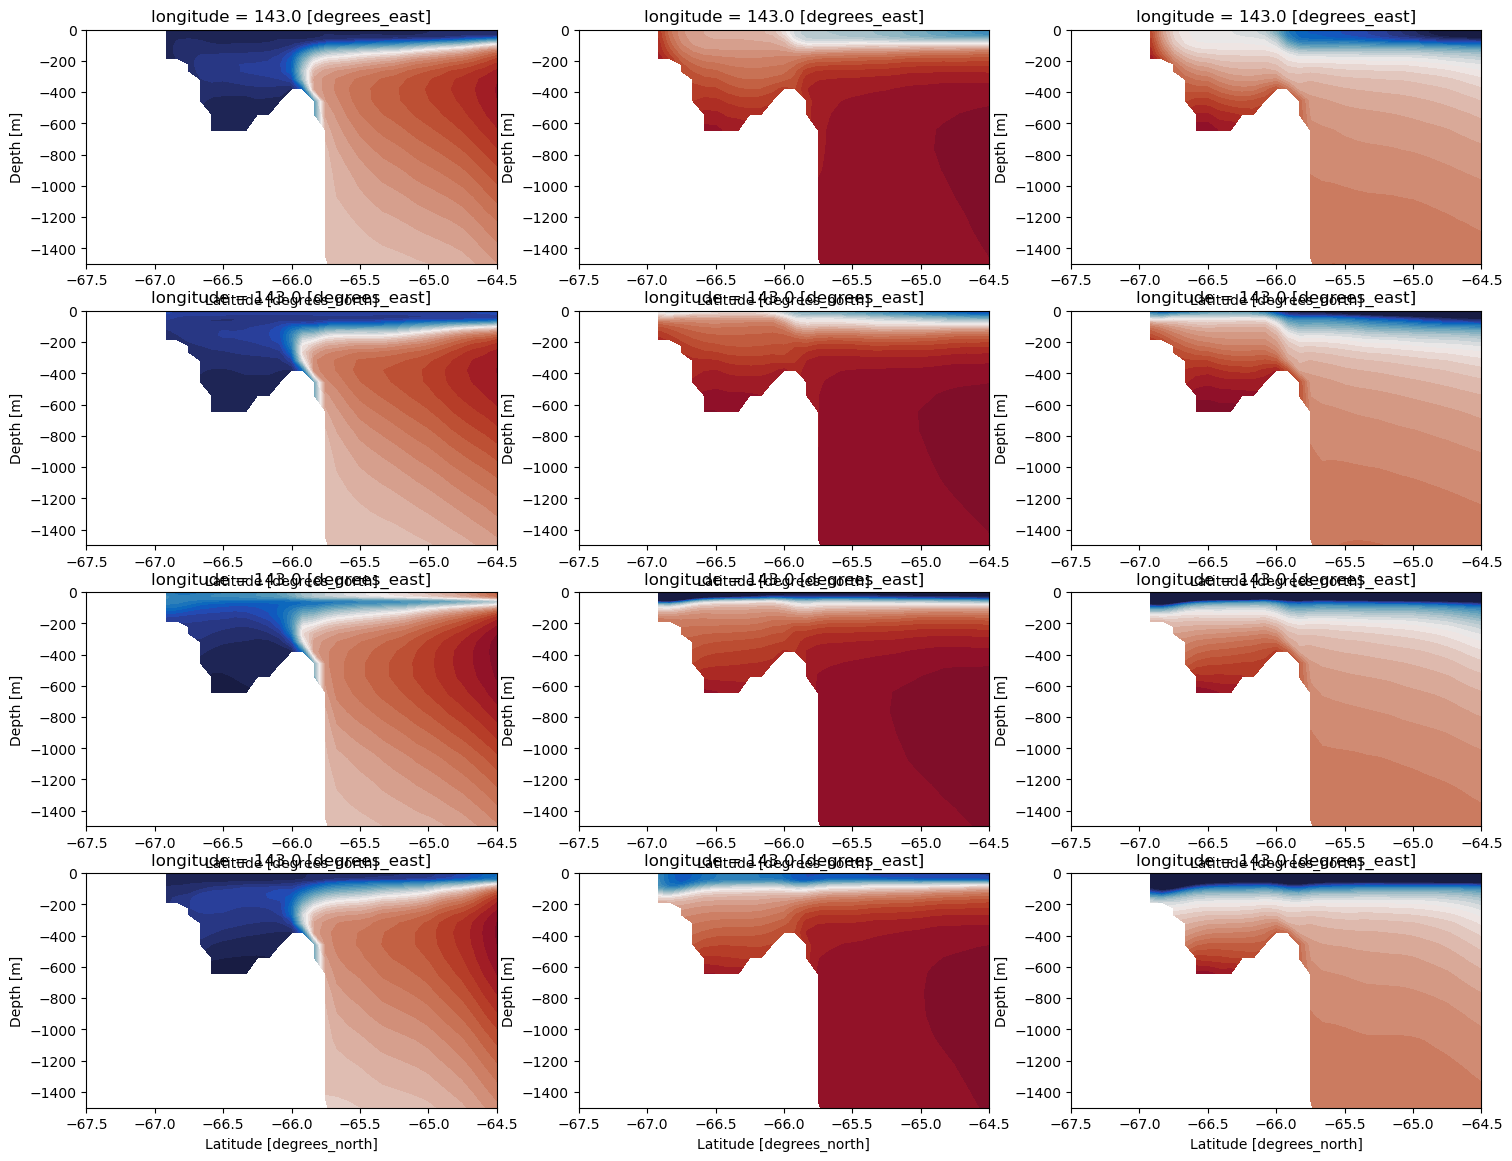

In [17]:
fig,axs = plt.subplots(4,3,figsize=(18,14))
for ssn,ax in zip(ssns,axs):
    plot_transect(ssns[ssn].ctemp.mean('time'),ax[0],'{} theta'.format(ssn),-2,2)
    plot_transect(ssns[ssn].asal.mean('time'),ax[1],'{} salinity'.format(ssn),34,35)
    plot_transect(ssns[ssn].sigma0.mean('time'),ax[2],'{} sigma0 '.format(ssn), 27.5, 28)


/tmp/ipykernel_3151481/571361276.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


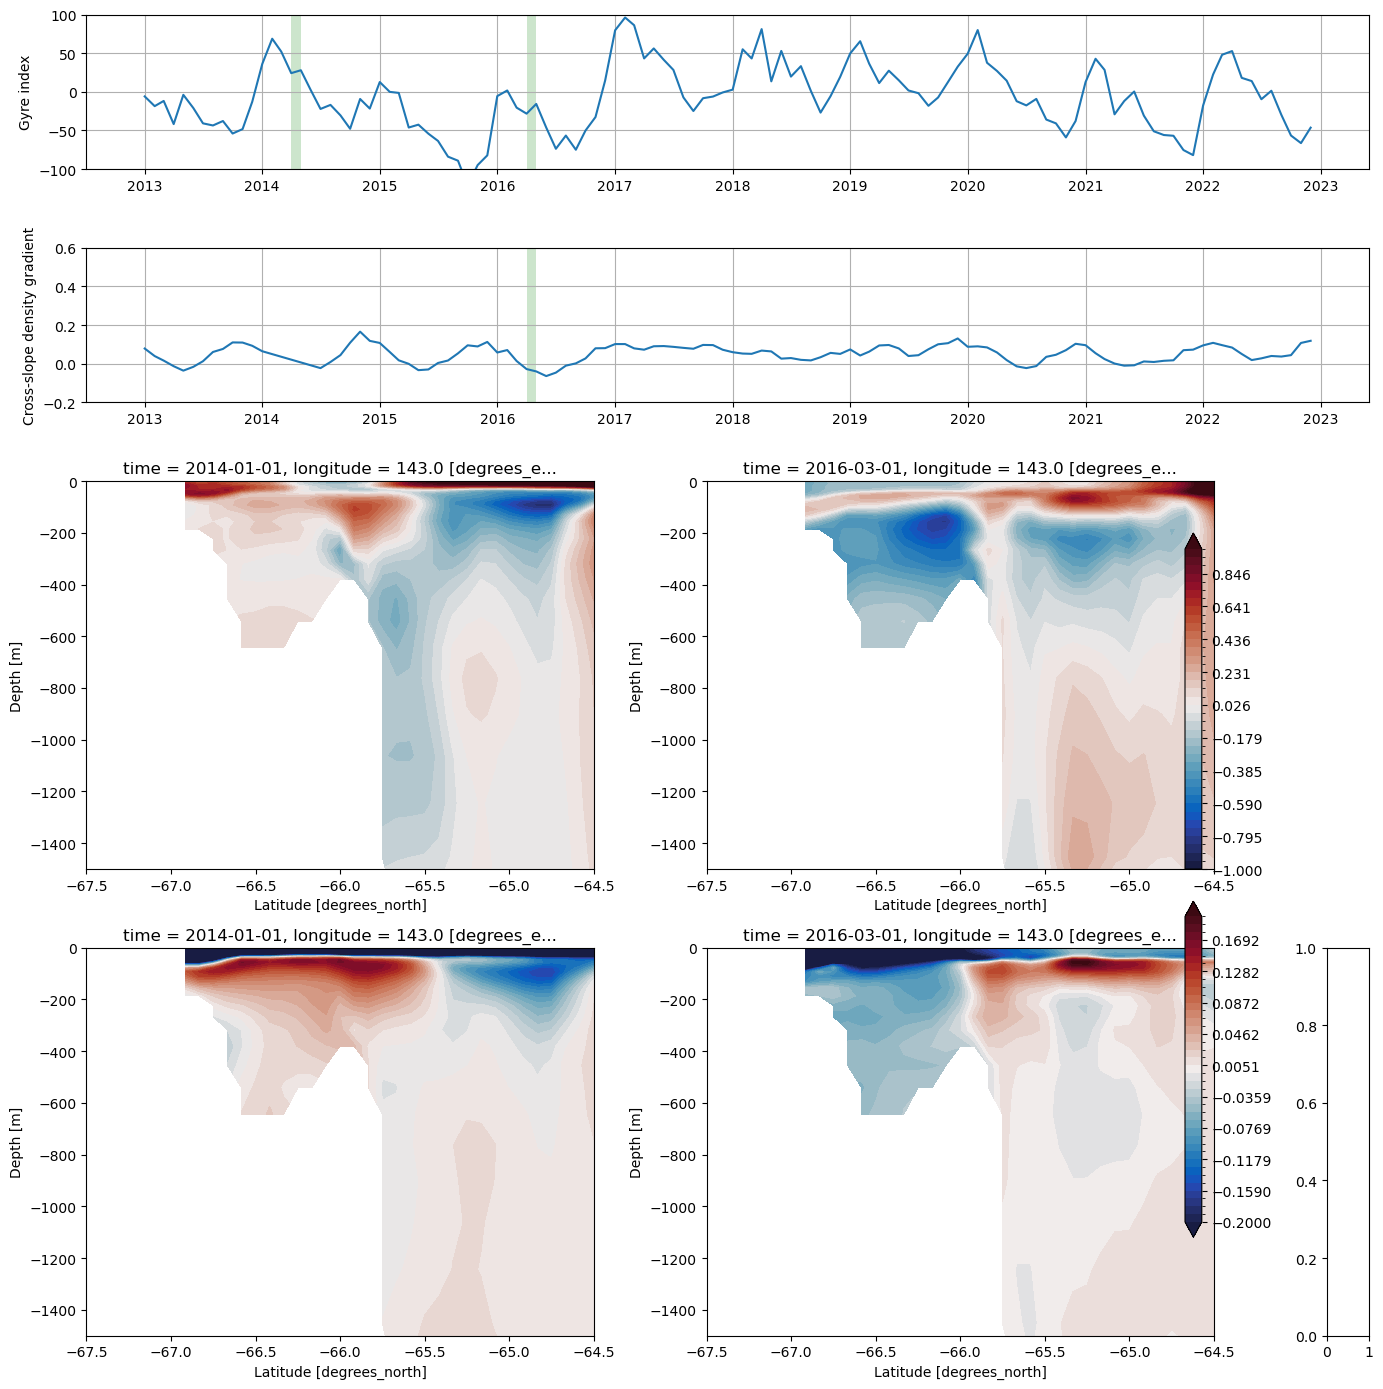

In [21]:
m=10
lag=5
t1 = pd.Timestamp(2013,m,1)
t2 = pd.Timestamp(2015,m,1)

txt='Summer '
ltxt = ' (' + txt + ' 2014, Weak Gyre)'
rtxt = ' (' + txt + ' 2016, Strong Gyre)'

def getdt(var):
    ts = utls.detrend_dim(glorys143[var],'time')
    return ts.sel(time = t1+rd(months=lag),method='nearest'), ts.sel(time = t2+rd(months=lag),method='nearest')


# fig,axs = plt.subplots(3,3,figsize=(16,12))
# ax = axs[0]
# tp,bt,ct = getdt('SIarea')
# ax[0].plot(tp.YC,tp)
# ax[0].set_title('Sea Ice Area' + ltxt)
# ax[0].set_ylim([-0.2,0.5])#[0,1])  
# ax[0].set_xlim([-67.5,-63.5])

# ax[1].plot(bt.YC,bt)
# ax[1].set_title('Sea Ice Area' + rtxt)
# ax[1].set_ylim([-0.2,0.5])#[0,1])  
# ax[1].set_xlim([-67.5,-63.5])

# ax[2].plot(bt.YC,ct)
# ax[2].set_title('Sea Ice Area' + rtxt)
# ax[2].set_ylim([-0.2,0.5])#[0,1])  
# ax[2].set_xlim([-67.5,-63.5])
fig = plt.figure(figsize=(14,14))
gs = fig.add_gridspec(6,9)

ax = fig.add_subplot(gs[0, :])
git = glorys_gi.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(git.time,git)
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+3)
    tboo = (git.time > t1a) & (git.time < t2a)
    
    ax.fill_between(git.time, -100,100, where=tboo, alpha=0.2, facecolor='green',label='lalala')
ax.grid()
ax.set_ylim([-100,100])
ax.set_ylabel('Gyre index')

ax = fig.add_subplot(gs[1,:])
sdt = sigdiff.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(sdt.time,sdt)
ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+3)
    tboo = (sdt.time > t1a) & (sdt.time < t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='green',label='lalala')
ax.set_ylim([-0.2,0.6])
ax.set_ylabel('Cross-slope density gradient')


ax1=fig.add_subplot(gs[2:4,0:4])
ax2=fig.add_subplot(gs[2:4,4:8])

tp,bt = getdt('thetao')
plot_transect(tp,ax1,'Temperature' + ltxt,-1,1)#-1.5,1.5)
im=plot_transect(bt,ax2,'Temperature'+rtxt,-1,1)#.5,1.5)
cbar_ax = fig.add_axes([0.85, 0.375, 0.012, 0.24])
fig.colorbar(im, cax=cbar_ax)

ax1=fig.add_subplot(gs[4:6,0:4])
ax2=fig.add_subplot(gs[4:6,4:8])
ax3=fig.add_subplot(gs[4:6,8:12])

tp,bt = getdt('so')
plot_transect(tp,ax1,'Salinity' +ltxt,-0.2,0.2)#34.2,34.8)
im=plot_transect(bt,ax2,'Salinity'+rtxt,-0.2,0.2)#34.2,34.8)

#fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.112, 0.012, 0.24])
fig.colorbar(im, cax=cbar_ax)

plt.tight_layout()


KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

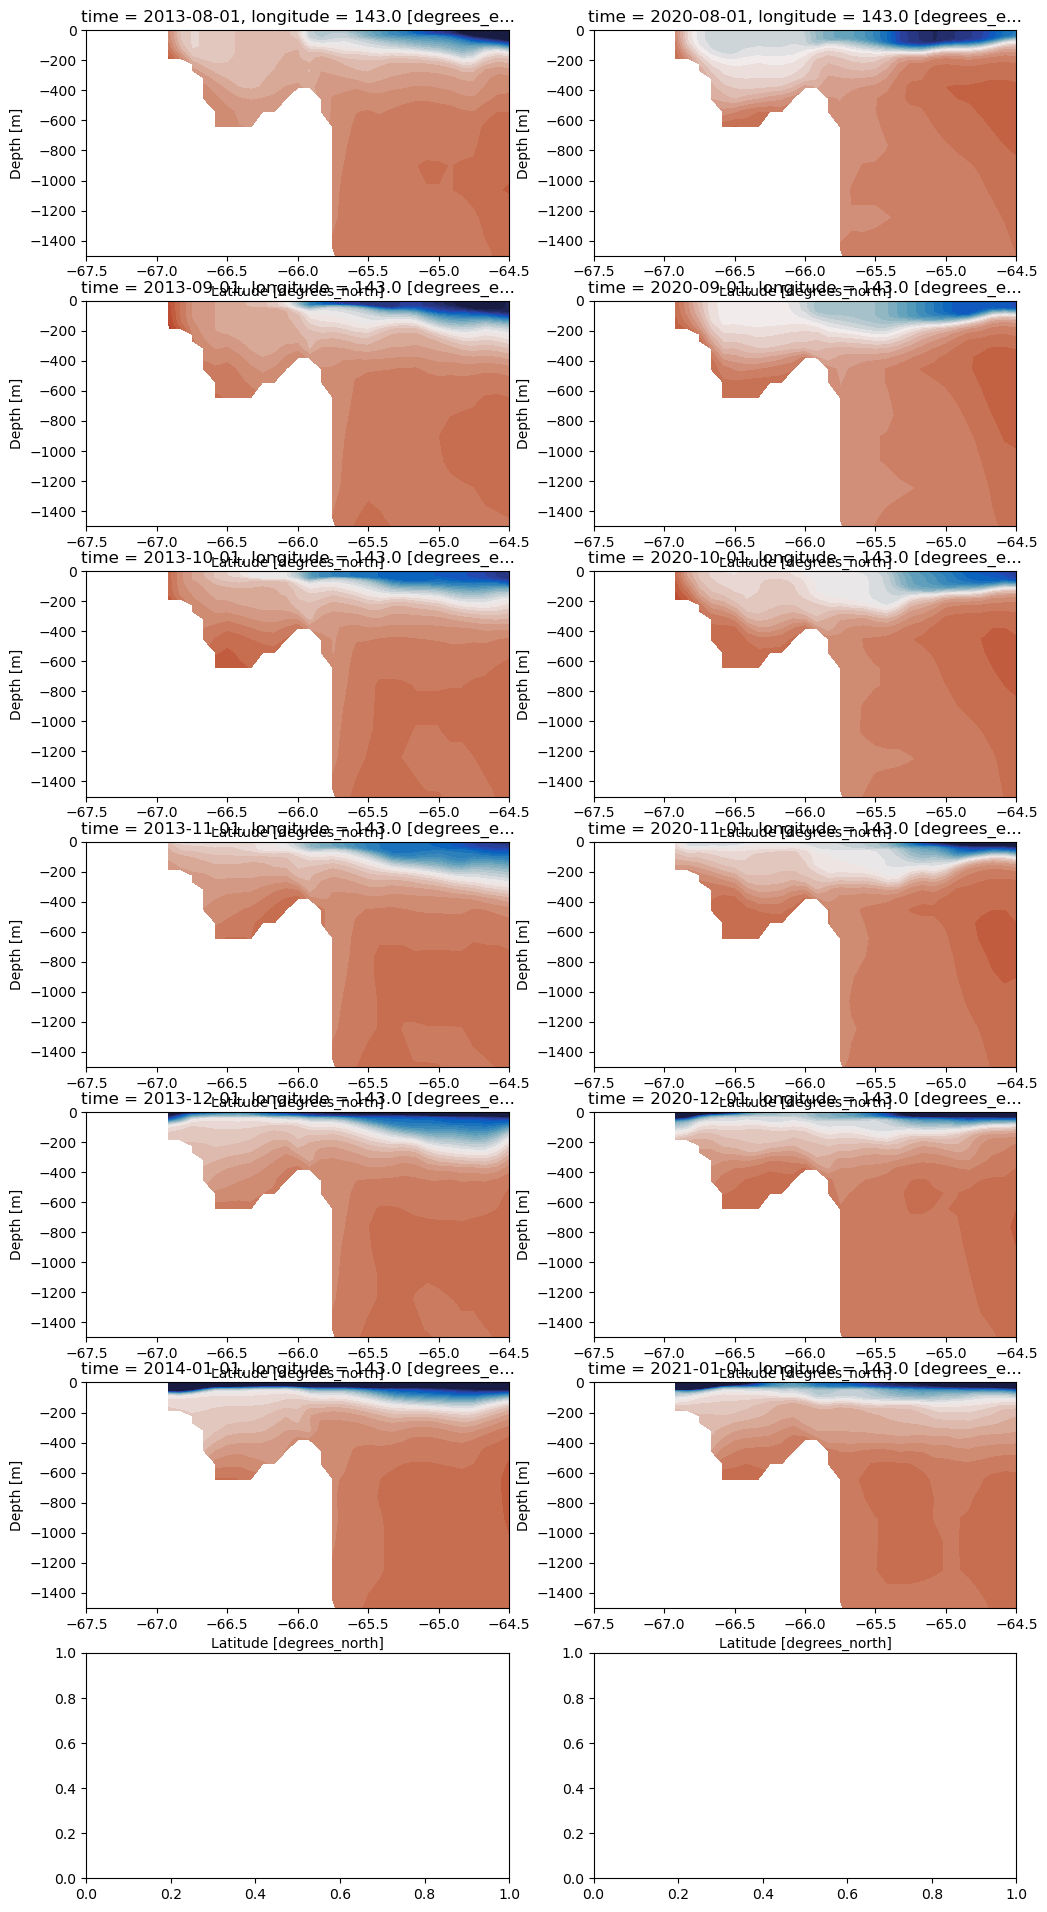

In [19]:
t1 = pd.Timestamp(2013,8,1)
t2 = pd.Timestamp(2020,8,1)

fig,axs = plt.subplots(7,2,figsize=(12,24))
n=1.5
for m in np.arange(7):
    sose145t = glorys143.so.sel(time = t1+rd(months=m))
    plot_transect(sose145t,axs[m][0],'salinity {} months after SLA/SIC max, ACC min'.format(m),34,35)
    sose145t = glorys143.so.sel(time = t2+rd(months=m))
    plot_transect(sose145t,axs[m][1],'salinity {} months after SLA/SIC min, ACC max'.format(m),34,35)



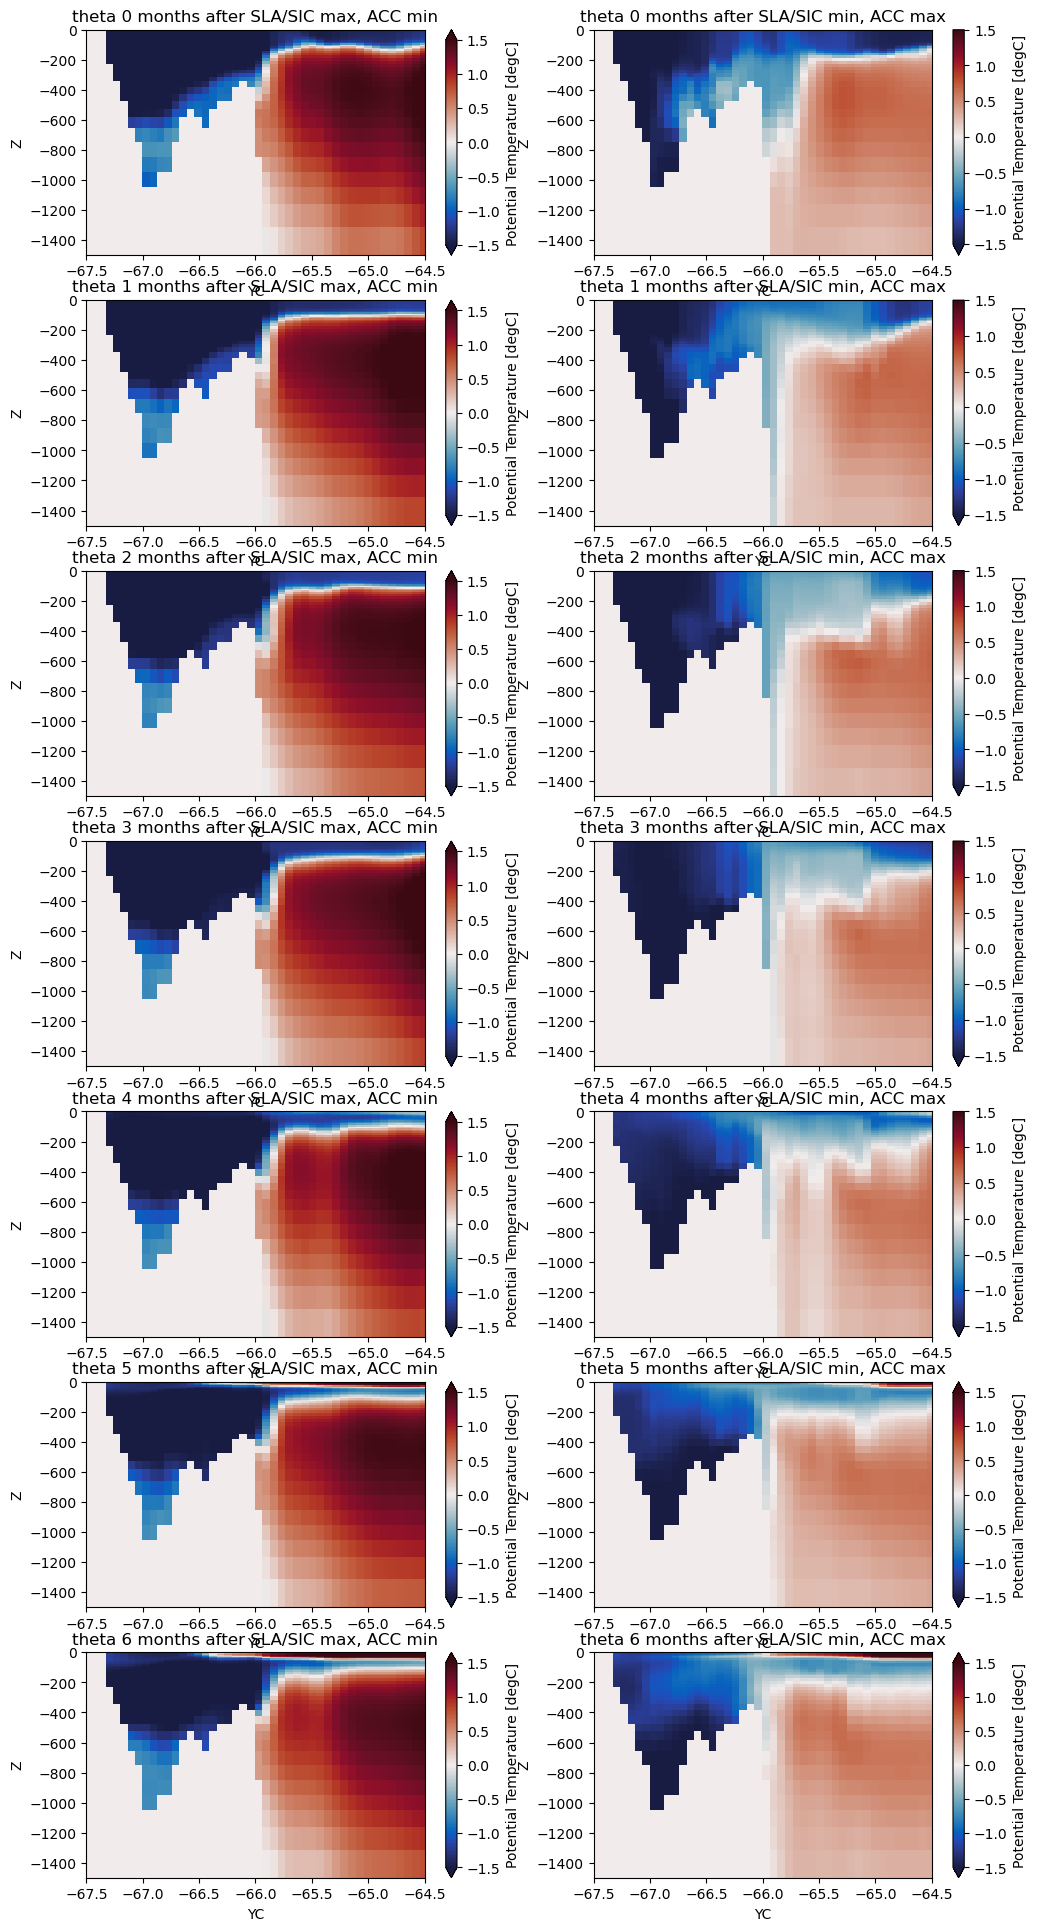

In [ ]:
t1 = pd.Timestamp(2013,9,1)
t2 = pd.Timestamp(2020,9,1)

fig,axs = plt.subplots(7,2,figsize=(12,24))
n=1.5
for m in np.arange(7):
    sose145t = ds145.THETA.sel(time = t1+rd(months=m))
    plot_transect(sose145t,axs[m][0],'theta {} months after SLA/SIC max, ACC min'.format(m),-n,n)
    sose145t = ds145.THETA.sel(time = t2+rd(months=m))
    plot_transect(sose145t,axs[m][1],'theta {} months after SLA/SIC min, ACC max'.format(m),-n,n)



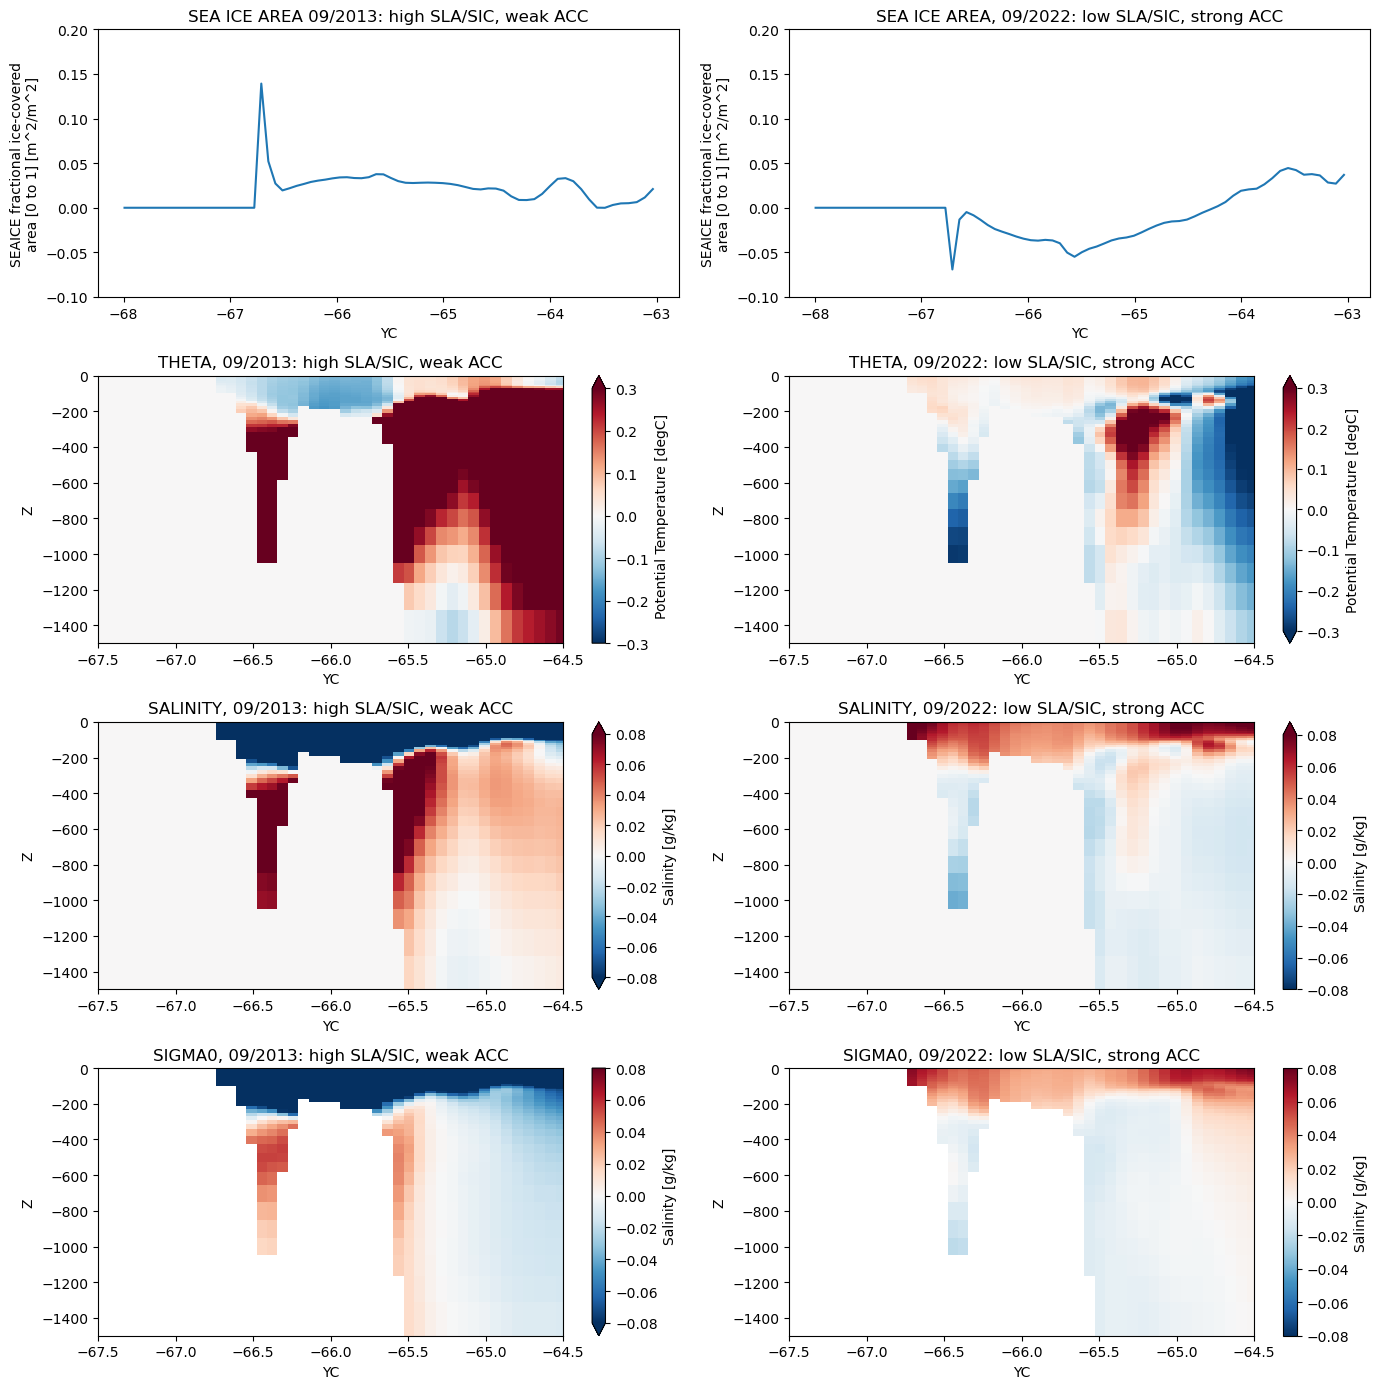

In [ ]:


sosemin=sa_sose_140.sel(time=tmin,method='nearest')
sosemax=sa_sose_140.sel(time=tmax,method='nearest')

fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500

mintxt = '09/2013: high SLA/SIC, weak ACC'
maxtxt = '09/2022: low SLA/SIC, strong ACC'

ax = axs[0]
sosemin.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA ' + mintxt)
ax[0].set_ylim([-0.1,0.2])

sosemax.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, ' + maxtxt)
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(sosemin.THETA,ax[0],'THETA, '+mintxt,-0.3)
plot_transect(sosemax.THETA,ax[1],'THETA, '+maxtxt,-0.3)

ax = axs[2]
plot_transect(sosemin.SALT,ax[0],'SALINITY, '+mintxt,-0.08)
plot_transect(sosemax.SALT,ax[1],'SALINITY, '+maxtxt,-0.08)

ax = axs[3]
plot_transect(sosemin.sigma0,ax[0],'SIGMA0, '+mintxt,-0.08)
plot_transect(sosemax.sigma0,ax[1],'SIGMA0, '+maxtxt,-0.08)
plt.tight_layout()


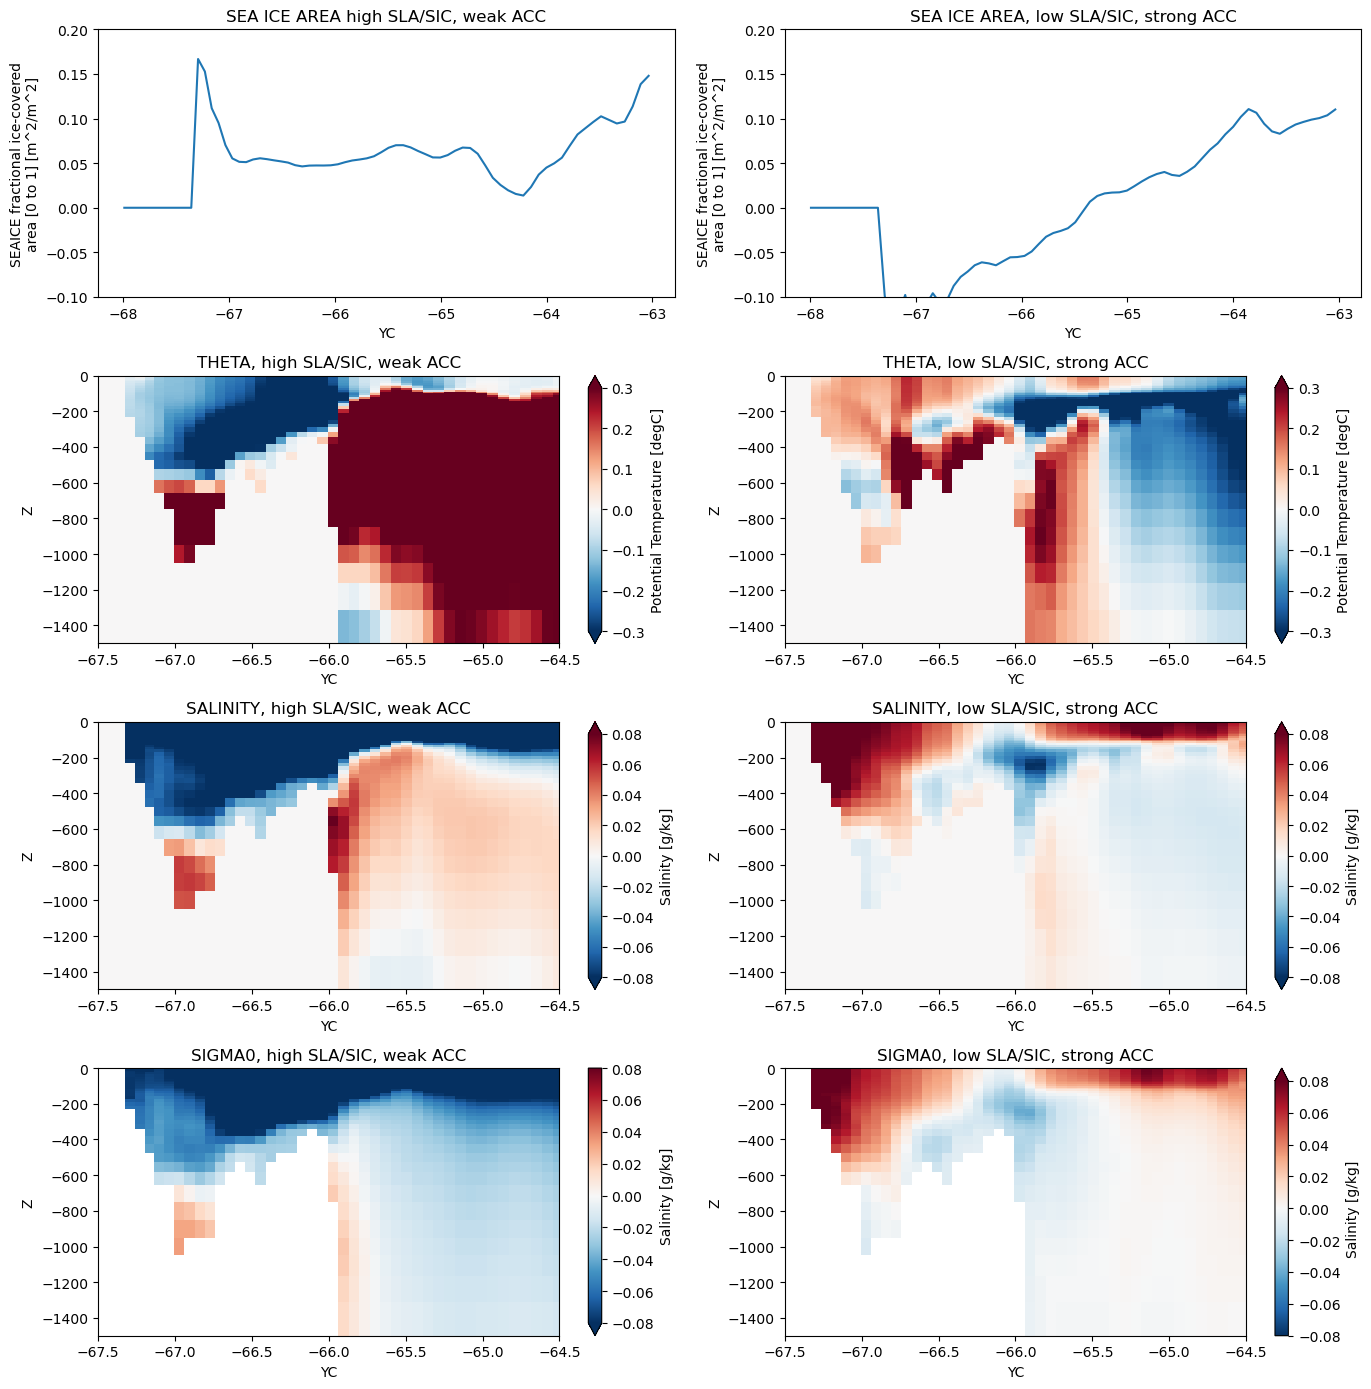

In [ ]:

sosemin=sa_sose_145.sel(time=tmin,method='nearest')
sosemax=sa_sose_145.sel(time=tmax,method='nearest')

fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500

mintxt = 'high SLA/SIC, weak ACC'
maxtxt = 'low SLA/SIC, strong ACC'

ax = axs[0]
sosemin.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA ' + mintxt)
ax[0].set_ylim([-0.1,0.2])

sosemax.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, ' + maxtxt)
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(sosemin.THETA,ax[0],'THETA, '+mintxt,-0.3)
plot_transect(sosemax.THETA,ax[1],'THETA, '+maxtxt,-0.3)

ax = axs[2]
plot_transect(sosemin.SALT,ax[0],'SALINITY, '+mintxt,-0.08)
plot_transect(sosemax.SALT,ax[1],'SALINITY, '+maxtxt,-0.08)

ax = axs[3]
plot_transect(sosemin.sigma0,ax[0],'SIGMA0, '+mintxt,-0.08)
plot_transect(sosemax.sigma0,ax[1],'SIGMA0, '+maxtxt,-0.08)
plt.tight_layout()


In [ ]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_asc,frac)
fns.run_for_idx(sa_asc,frac,sa_sla,sa_geos,'SLA',extent_ac,lag=lag,ylim_idx=10,ylim1=6)
fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
tops = top(sa_sose_145,lag)#ssn_sose[s],lag)
bots = bot(sa_sose_145,lag)#ssn_sose[s],lag)


ax = axs[0]
tops.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA, high ASC')
ax[0].set_ylim([-0.1,0.2])

bots.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, low ASC')
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(tops.THETA,ax[0],'THETA, high ASC',-0.3)
plot_transect(bots.THETA,ax[1],'THETA, low ASC',-0.3)

ax = axs[2]
plot_transect(tops.SALT,ax[0],'SALINITY, high ASC',-0.08)
plot_transect(bots.SALT,ax[1],'SALINITY, low ASC',-0.08)

ax = axs[3]
plot_transect(tops.sigma0,ax[0],'SIGMA0, high ASC',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, low ASC',-0.08)
plt.tight_layout()


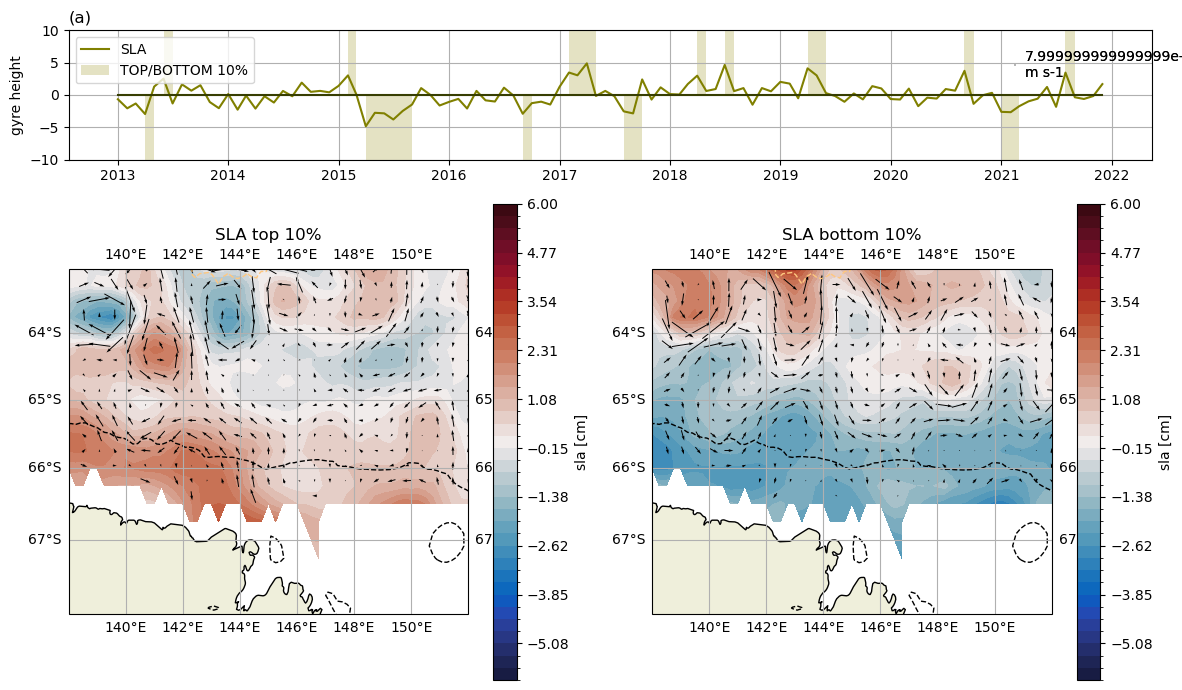

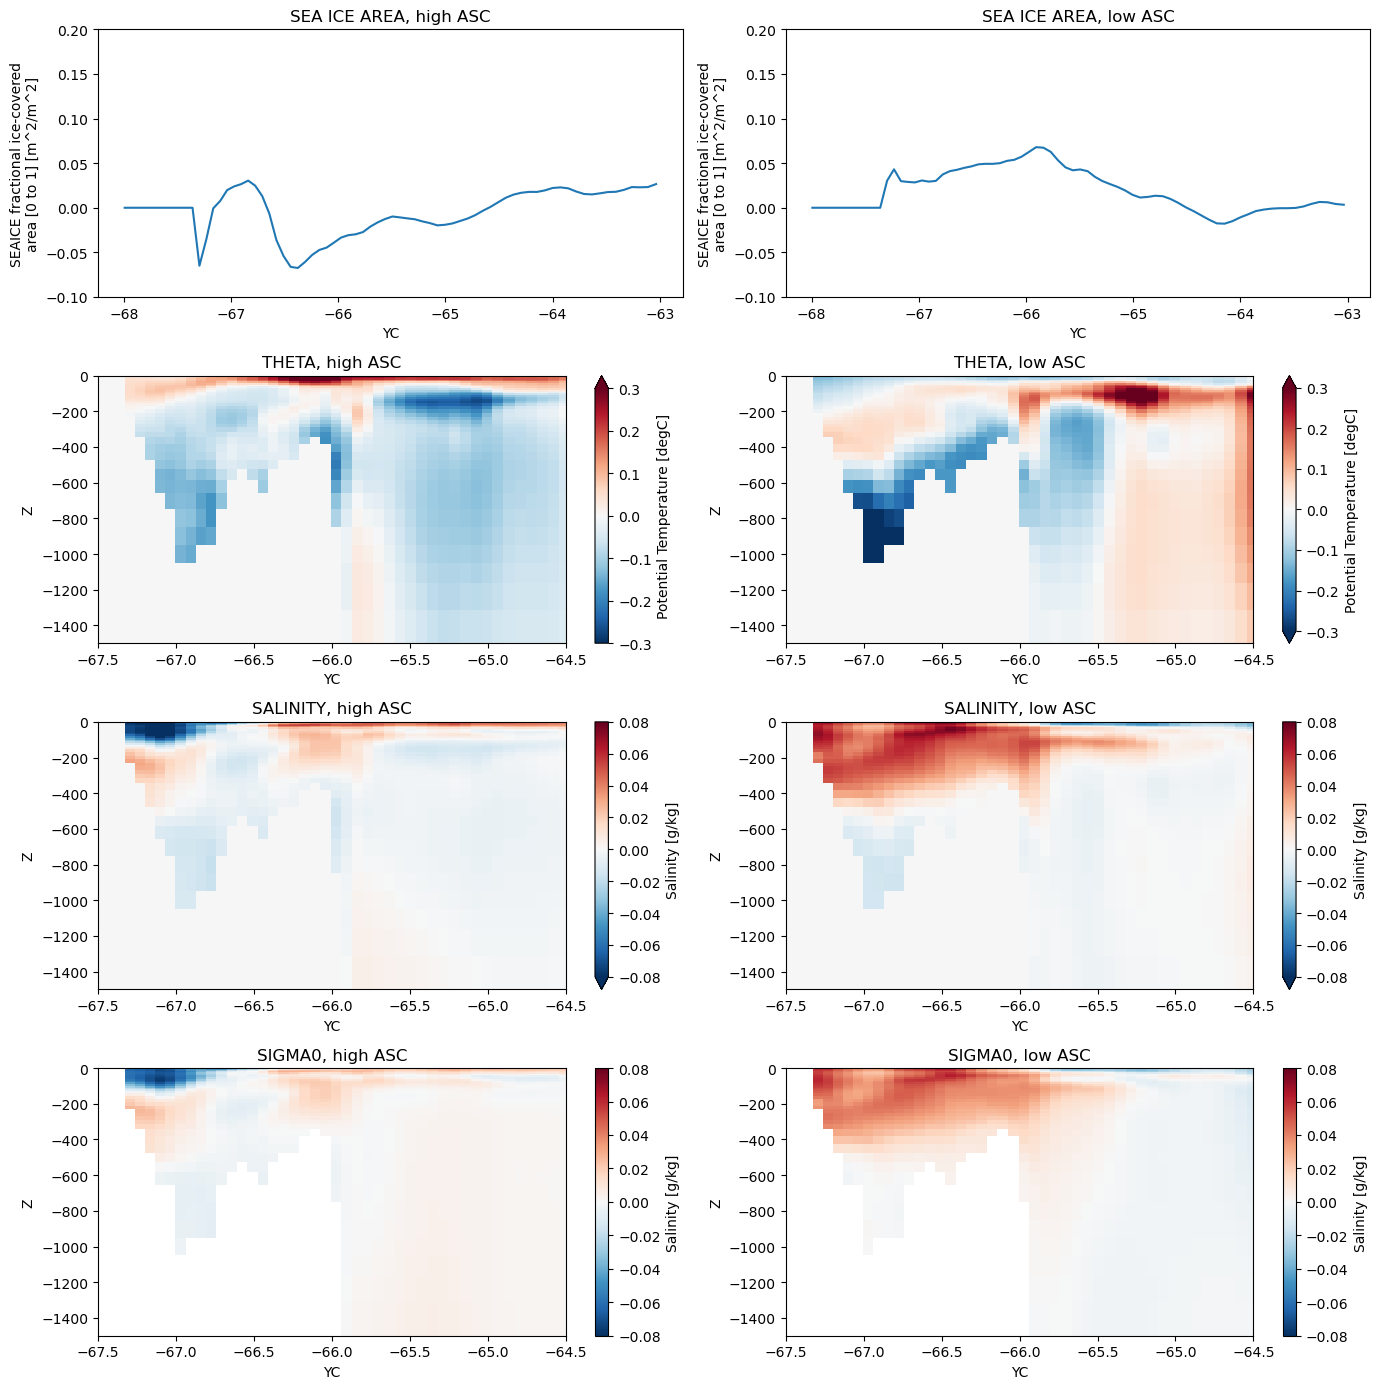

In [ ]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_asc,frac)
fns.run_for_idx(sa_asc,frac,sa_sla,sa_geos,'SLA',extent_ac,lag=lag,ylim_idx=10,ylim1=6)
fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
tops = top(sa_sose_145,lag)#ssn_sose[s],lag)
bots = bot(sa_sose_145,lag)#ssn_sose[s],lag)


ax = axs[0]
tops.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA, high ASC')
ax[0].set_ylim([-0.1,0.2])

bots.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, low ASC')
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(tops.THETA,ax[0],'THETA, high ASC',-0.3)
plot_transect(bots.THETA,ax[1],'THETA, low ASC',-0.3)

ax = axs[2]
plot_transect(tops.SALT,ax[0],'SALINITY, high ASC',-0.08)
plot_transect(bots.SALT,ax[1],'SALINITY, low ASC',-0.08)

ax = axs[3]
plot_transect(tops.sigma0,ax[0],'SIGMA0, high ASC',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, low ASC',-0.08)
plt.tight_layout()


In [16]:
# mean on shelf
shelf140 = sa_sose_140.where(sa_sose_140.Depth < 1000,drop=True)
shelf145 = sa_sose_145.where(sa_sose_145.Depth < 1000,drop=True)

In [17]:
shelf140.to_netcdf('sose_shelf_140.nc')
shelf145.to_netcdf('sose_shelf_145.nc')

(-2500.0, 0.0)

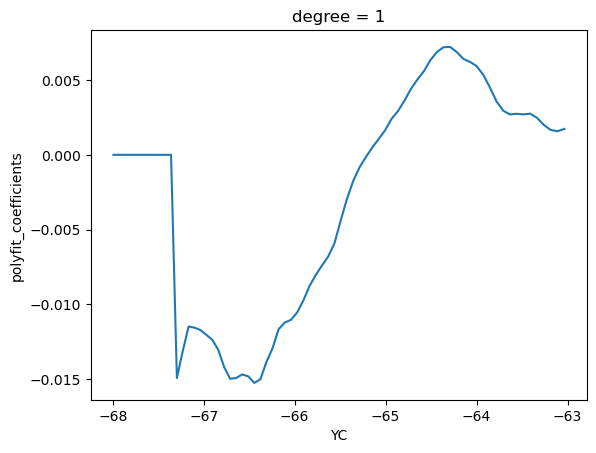

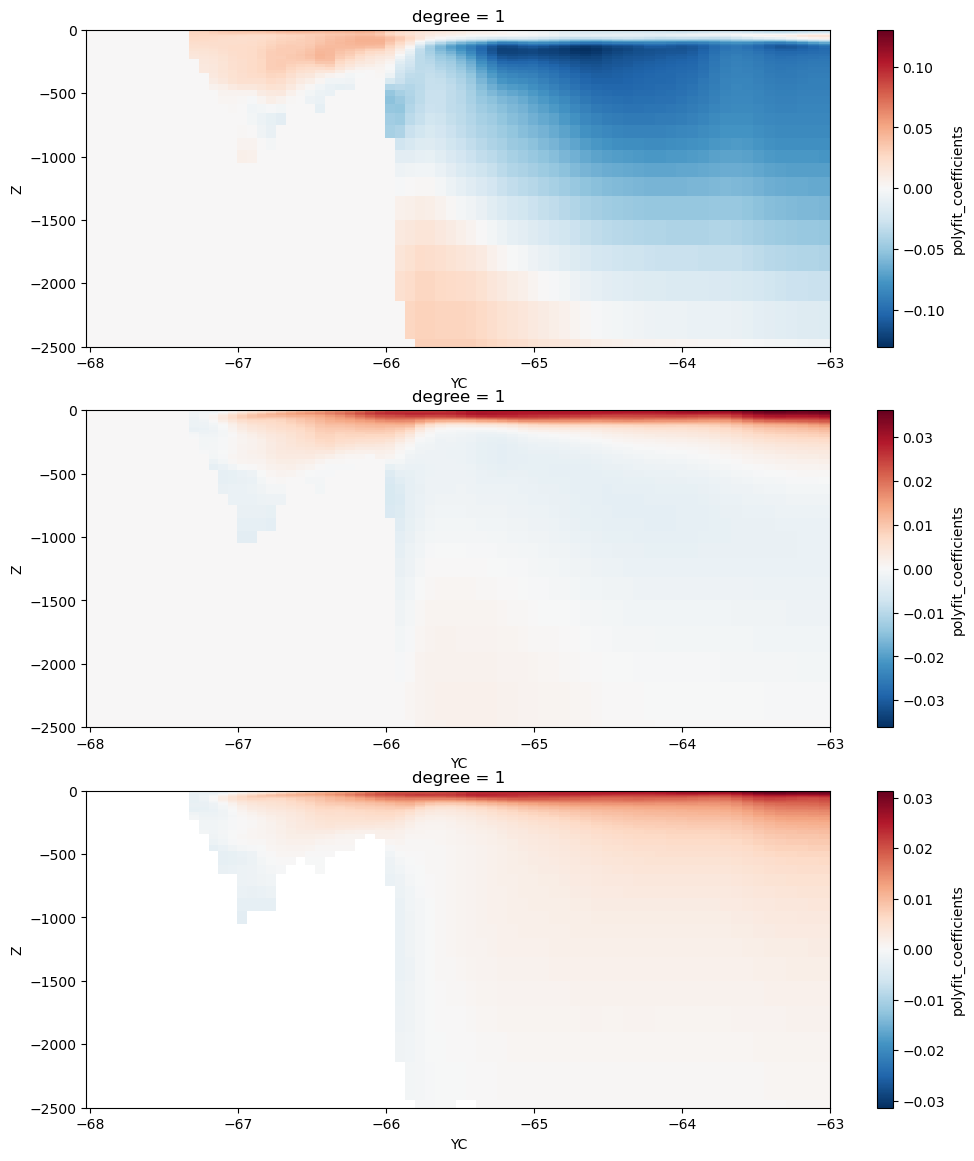

In [18]:
theta_trend = fns.get_trend(ds145.THETA)
psal_trend = fns.get_trend(ds145.SALT)
sigma_trend = fns.get_trend(ds145.sigma0)
ice_trend = fns.get_trend(ds145.SIarea)

ice_trend.plot()
fig,axs = plt.subplots(3,1,figsize=(12,14))

ax=axs[0]
theta_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[1]
psal_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[2]
sigma_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

In [19]:
def get_xht(ds):
    ds['thetav'] = ds.THETA.interp({'YC':ds.YG})
    ds['thetavvel'] = ds.thetav * ds.VVEL
    ds['xht'] = -ds.thetavvel.integrate('Z')

xhtl = 'Northward Cross-Shelf Heat Transport'

In [20]:
get_xht(ds145)
get_xht(ds140)
get_xht(dsseg)

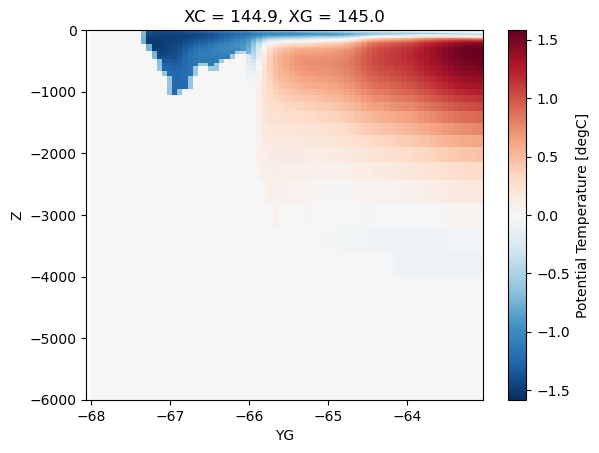

In [21]:
ds145.thetav.mean('time').plot()


In [22]:
dsseg.UVEL

<xarray.DataArray 'UVEL' (time: 132, Z: 52, YC: 15, XG: 73)> Size: 30MB
array([[[[-0.11351591, -0.11364583, -0.11296034, ...,  0.06365241,
           0.05605385,  0.04845608],
         [-0.11491787, -0.11417192, -0.1139613 , ...,  0.09973124,
           0.09602018,  0.08896291],
         [-0.11834333, -0.11746937, -0.11743579, ...,  0.12206987,
           0.12441859,  0.11733854],
         ...,
         [ 0.0398788 ,  0.04364948,  0.04595809, ...,  0.13930182,
           0.12694946,  0.11607305],
         [ 0.01643017,  0.01536007,  0.01059491, ...,  0.16416056,
           0.14661138,  0.13097905],
         [-0.01221673, -0.01309277, -0.01387892, ...,  0.19499932,
           0.17771335,  0.15916441]],

        [[-0.05202721, -0.05211634, -0.05117763, ...,  0.09590435,
           0.08733595,  0.07915246],
         [-0.05184802, -0.0508084 , -0.05058866, ...,  0.13302721,
           0.12842236,  0.12037734],
         [-0.05463448, -0.05352984, -0.05365966, ...,  0.1549296 ,
           0.15691453,  0.14893852],
...
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],

        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]]]],
      shape=(132, 52, 15, 73), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XG       (XG) float64 584B 138.0 138.2 138.3 138.5 ... 149.7 149.8 150.0
    dxC      (YC, XG) float64 9kB 7.545e+03 7.545e+03 ... 7.829e+03 7.829e+03
    dyG      (YC, XG) float64 9kB 7.545e+03 7.545e+03 ... 7.829e+03 7.829e+03
    rAw      (YC, XG) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacW    (Z, YC, XG) float64 456kB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
Attributes:
    standard_name:  UVEL
    long_name:      Zonal Component of Velocity (m/s)
    units:          m/s
    mate:           VVEL

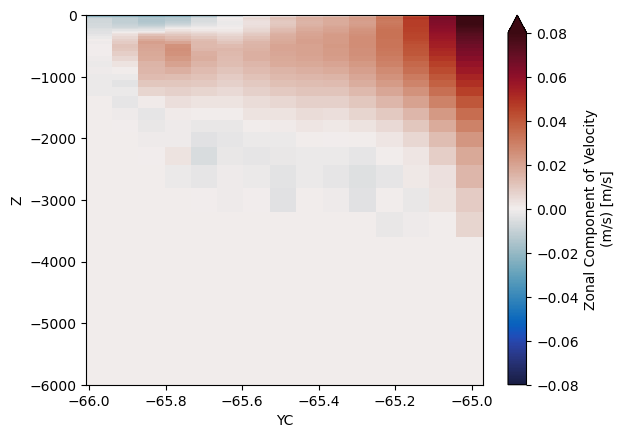

In [23]:
dsseg.UVEL.sel(time=slice(pd.Timestamp(2014,1,1),pd.Timestamp(2014,12,1))).mean('time').mean('XG').plot(cmap=cmocean.cm.balance,vmin=-0.08)

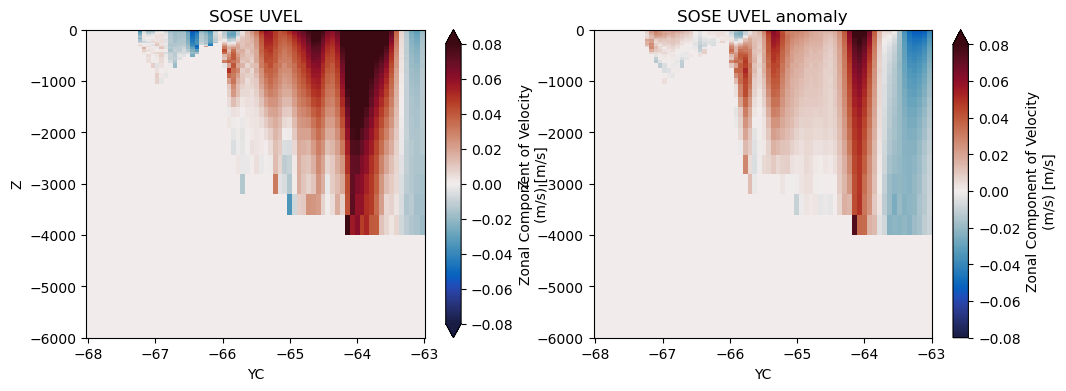

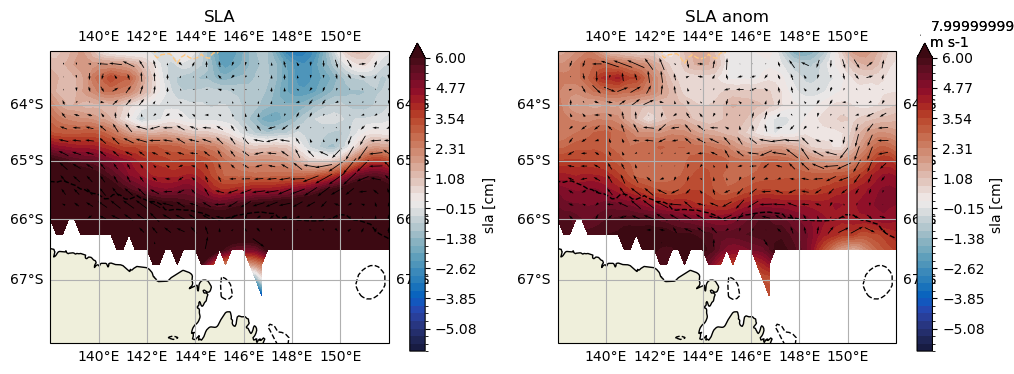

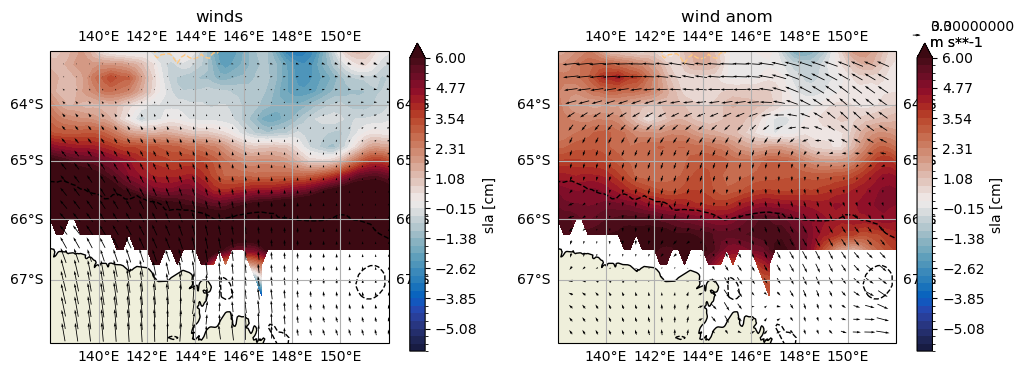

In [34]:
t1test=pd.Timestamp(2014,1,1)
t2test=pd.Timestamp(2014,12,1)

tcut = lambda ds: ds.sel(time=slice(t1test,t2test)).mean('time')


fig,ax = plt.subplots(1,2,figsize=(12,4))
tcut(ds145.UVEL).plot(ax=ax[0],cmap=cmocean.cm.balance,vmin=-0.08)
tcut(sa_sose_145.UVEL).plot(ax=ax[1],cmap=cmocean.cm.balance,vmin=-0.08)
ax[0].set_title('SOSE UVEL')
ax[1].set_title('SOSE UVEL anomaly')

fig,ax = plt.subplots(1,2,figsize=(12,4),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax[0],tcut(sla),'SLA',  extent_ac,-6,6,cmap=cmocean.cm.balance,vector=tcut(geos))
fns.plotc(ax[1],tcut(sa_sla),'SLA anom',extent_ac,-6,6,vector=tcut(sa_geos))

fig,ax = plt.subplots(1,2,figsize=(12,4),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax[0],tcut(sla),'winds',  extent_ac,-6,6,cmap=cmocean.cm.balance,vector=tcut(winds))
fns.plotc(ax[1],tcut(sa_sla),'wind anom',extent_ac,-6,6,vector=tcut(sa_winds))



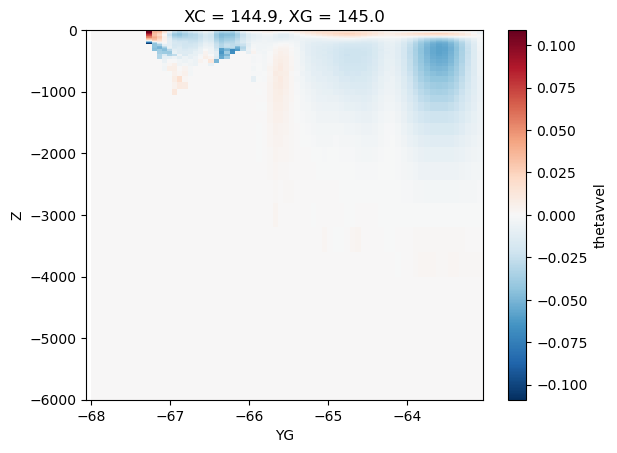

In [21]:
ds145.thetavvel.mean('time').plot()


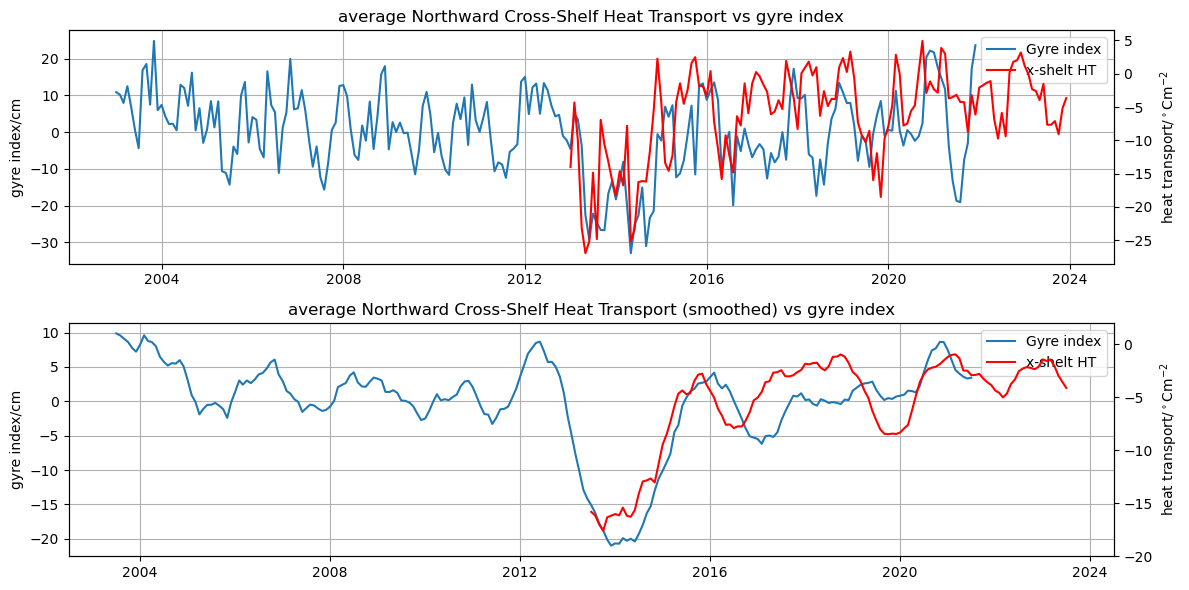

In [22]:
#repeat for l
dsl = ds145.sel(YG=slice(-67,-65)).mean('YG')#,method='nearest')

fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
ax2=ax.twinx()
l1 = ax.plot(gyre_index.time,gyre_index)
l2 = ax2.plot(dsl.time,dsl.xht,c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsl.time,dsl.xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' (smoothed) vs gyre index')
ax2.set_ylim([-20,2])

plt.tight_layout()



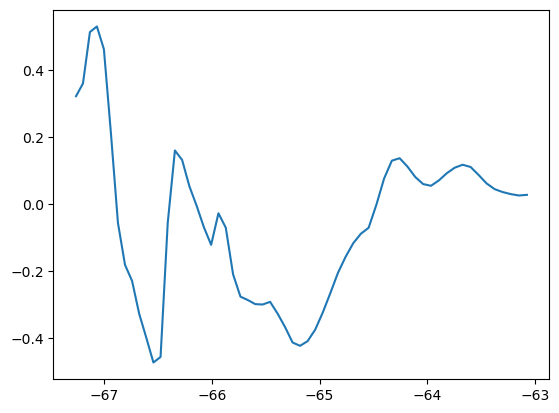

In [25]:
plt.plot(ds145.YG,corr)

In [24]:
corr=[]
maxl=0
gic = gyre_index.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
dsc = ds145.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
for yg in dsc.YG:
    dsyg = dsc.sel(YG=yg)
    xhtyg = dsyg.thetavvel.integrate('Z')
    cc = xr.corr(gic,xhtyg)
    corr.append(cc.item())
    

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


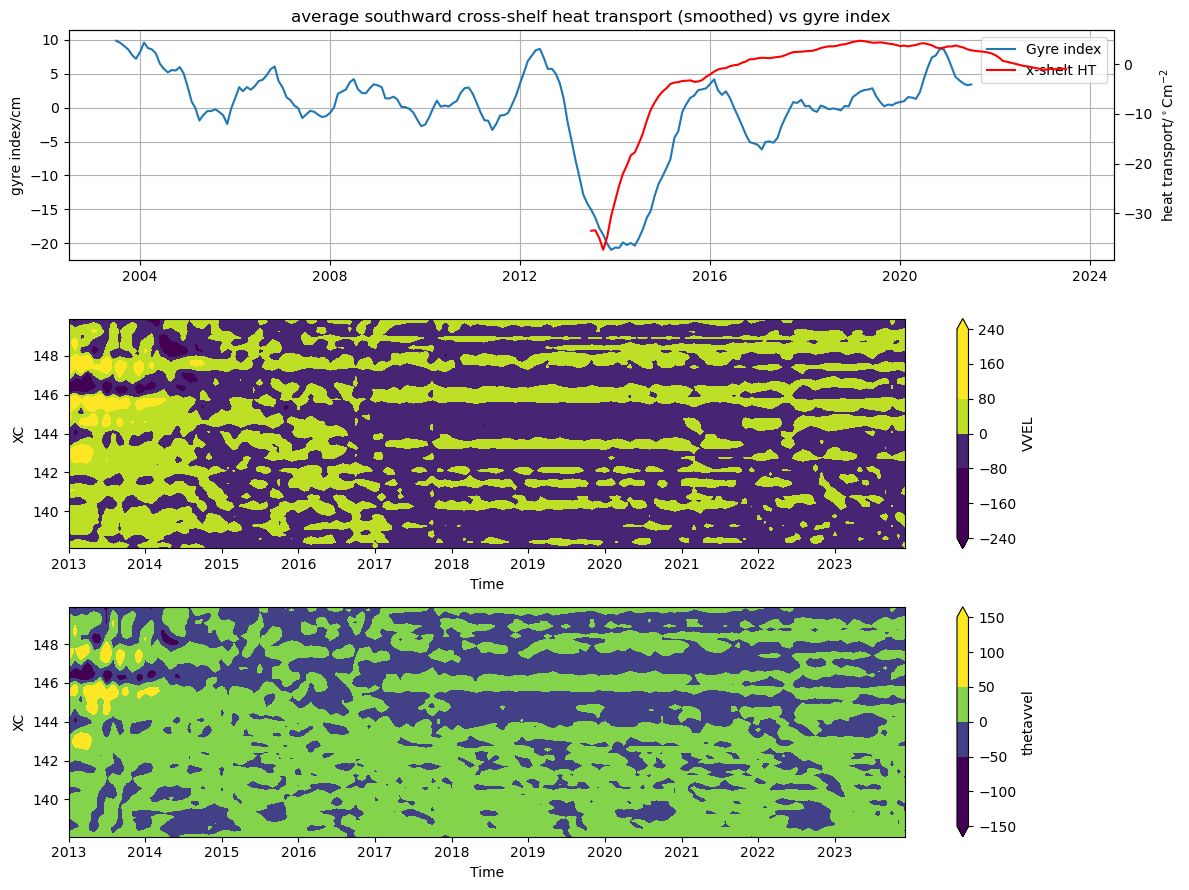

In [ ]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,9))
ax=axs[0]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsm.time,dsm.sel(XC=slice(144,146)).mean('XC').xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average southward cross-shelf heat transport (smoothed) vs gyre index')

ax=axs[1]
dsm.VVEL.integrate('Z').plot(ax=ax,x='time',y='XC',vmin=-50,vmax=50)

ax=axs[2]
dsm.thetavvel.integrate('Z').plot(ax=ax,x='time',y='XC',vmin=-40,vmax=40)


plt.tight_layout()

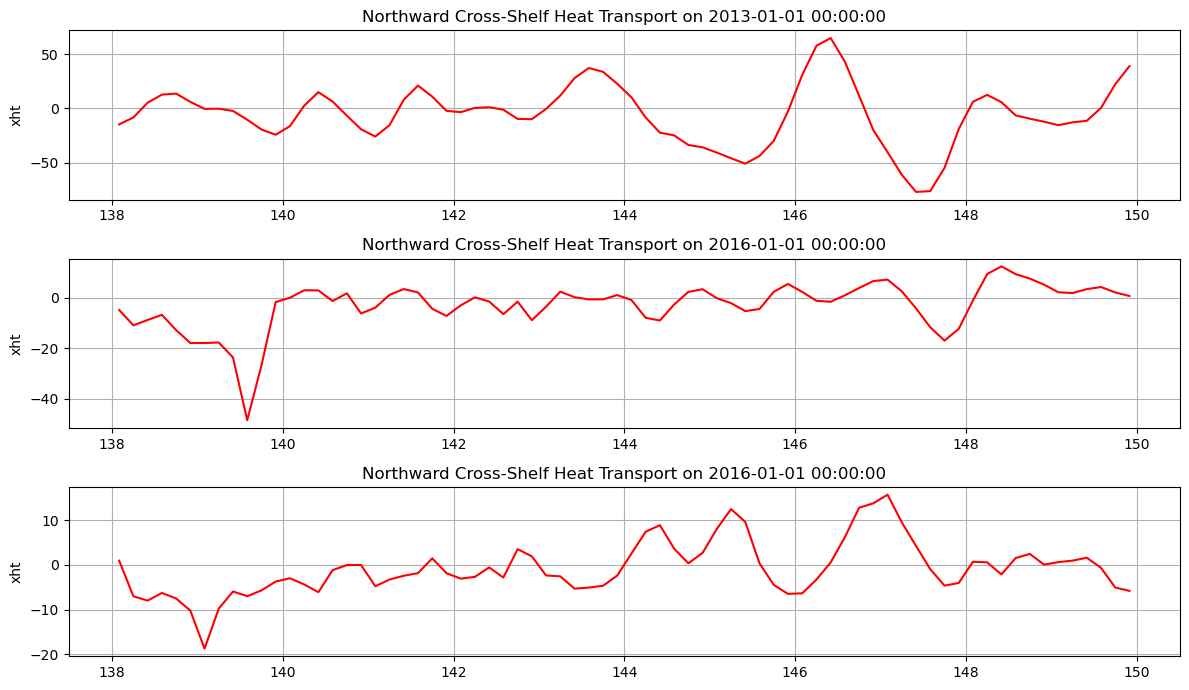

In [ ]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

ax=axs[0]
ax.plot(dsm.XC,dsm.sel(time=t1).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XC,dsm.sel(time=t2).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XC,dsm.sel(time=t3).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

plt.tight_layout()


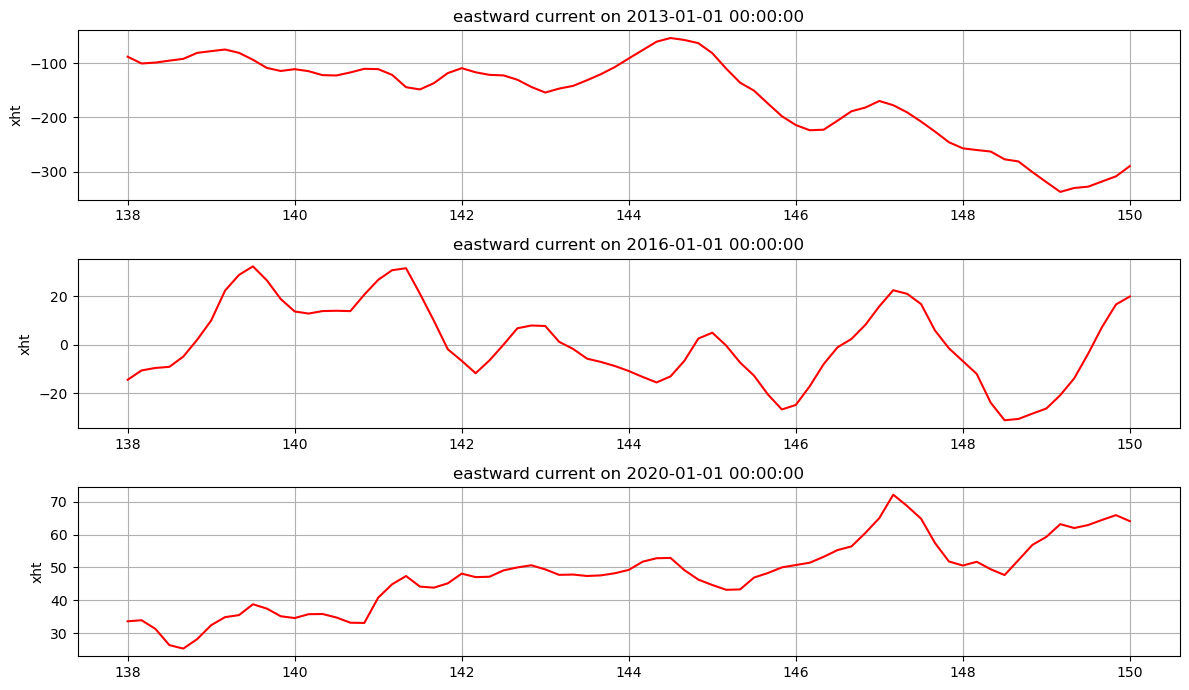

In [ ]:
dsm = dsseg.mean('YC')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

xhtl = 'eastward current'
ax=axs[0]
ax.plot(dsm.XG,dsm.sel(time=t1).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XG,dsm.sel(time=t2).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XG,dsm.sel(time=t3).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t3))

plt.tight_layout()

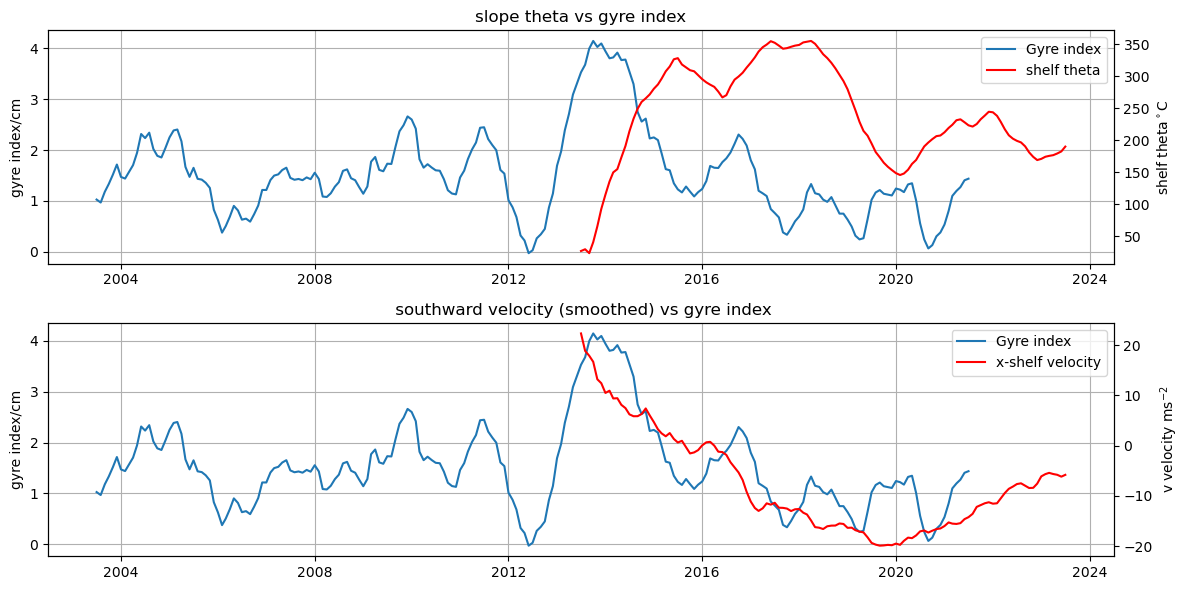

In [ ]:
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
l1 = ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax2=ax.twinx()
l2 = ax2.plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','shelf theta'])
ax.grid()
ax2.set_ylabel(r'shelf theta$^\circ$C')
ax.set_ylabel('gyre index/cm')
ax.set_title('slope theta vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelf velocity'])
ax.grid()
ax2.set_ylabel(r'v velocity ms$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title(' southward velocity (smoothed) vs gyre index')

plt.tight_layout()

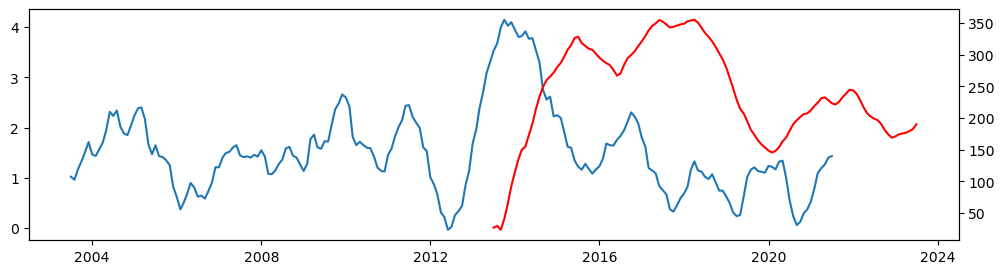

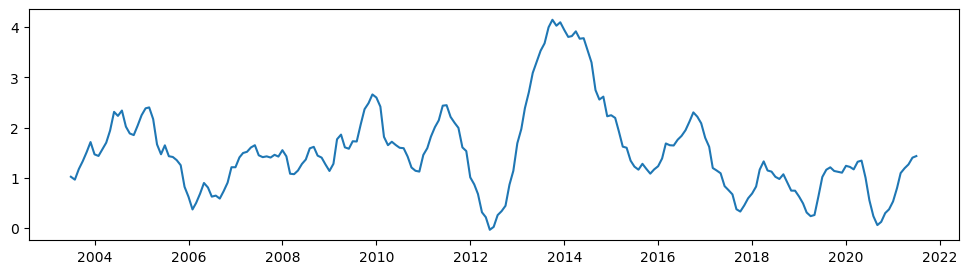

In [ ]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())


In [ ]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


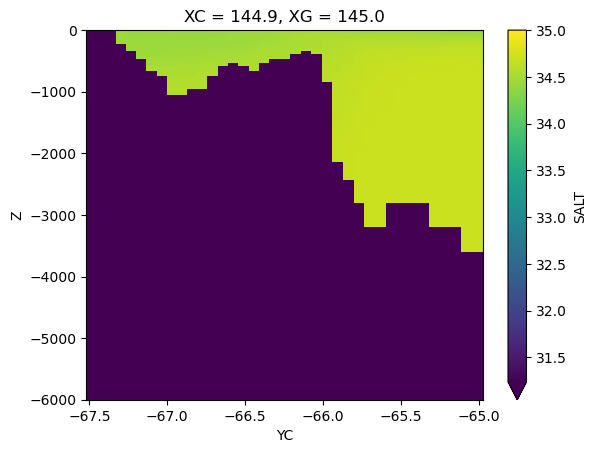

In [21]:
s_salty['spring'].mean('time').plot(vmin=35)

In [22]:
dss = fns.season_split(ds.sigma0)

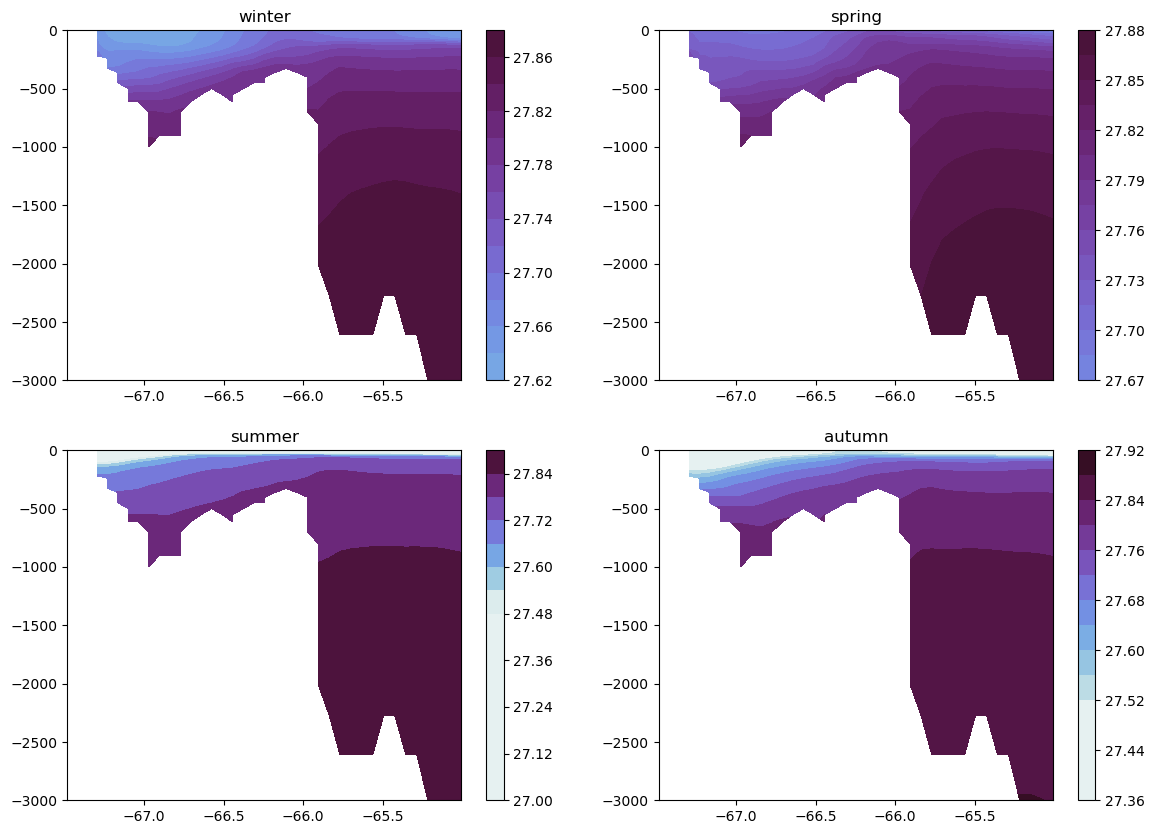

In [23]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [ ]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')